In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
#from sklearn.cross_decomposition import CCA
from mvlearn.embed import CCA
from scipy.stats import pearsonr 
from scipy import stats
from typing import List, Tuple, Optional
import numpy as np


###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

In [2]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#", skiprows=1,
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                eeg_norm = normalise_eeg(eeg)           # your helper from before
                pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg_norm), len(pupil_z))
                eeg_norm = eeg_norm[0:T, :]  # (T × n_channels)
                pupil_z  = pupil_z[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg_norm, pupil_z, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials
    
def split_trials_by_load(trials: List[Tuple[np.ndarray, np.ndarray, dict]]
                         ) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into 05, 09 and 13 load sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'load'.

    Returns
    -------
    load_05_trials  : list[tuple]
    load_09_trials  : list[tuple]
    load_13_trials  : list[tuple]
    """
    load_05_trials = []
    load_09_trials = []
    load_13_trials = []

    for eeg, pupil, meta in trials:
        load = meta.get("load")
        if load == 5:
            load_05_trials.append((eeg, pupil, meta))
        elif load == 9:
            load_09_trials.append((eeg, pupil, meta))
        elif load == 13:
            load_13_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown load label: {load}")

    return load_05_trials, load_09_trials, load_13_trials

In [3]:
from typing import List, Tuple, Optional, Dict
def concat_trials(
    trials: List[Tuple[np.ndarray, np.ndarray, dict]],
    shift: int = 0,  # samples; positive = EEG delayed (EEG after pupil)
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate trials for CCA without circular wrap.

    Returns
    -------
    X : ndarray, shape (Σ T_eff, n_channels)   # EEG
    Y : ndarray, shape (Σ T_eff, 1)            # pupil
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # Ensure 1D/2D shapes: EEG (T, C), pupil (T, 1)
        if eeg.ndim == 1:
            eeg = eeg[:, None]
        if pupil_z.ndim == 1:
            pupil_z = pupil_z[:, None]

        T = min(len(eeg), len(pupil_z))
        if T == 0:
            print("Warning: zero-length trial encountered - skipped")
            continue

        # Optional common window first (keeps boundaries away)
        start = WIN_OFFSET1
        stop  = T - WIN_OFFSET2
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]
        Tw = len(eeg_w)

        # Apply lag by asymmetric trimming (no roll, no wrap)
        # Positive shift => EEG delayed => drop 'shift' from EEG start and pupil end
        # Negative shift => EEG advanced => drop '-shift' from pupil start and EEG end
        if shift >= 0:
            if Tw <= shift:
                continue  # nothing left after lag
            eeg_seg   = eeg_w[shift:]             # drop early EEG
            pupil_seg = pupil_w[:Tw - shift]      # drop late pupil
        else:
            s = -shift
            if Tw <= s:
                continue
            eeg_seg   = eeg_w[:Tw - s]            # drop late EEG
            pupil_seg = pupil_w[s:]               # drop early pupil

        # Shapes now match
        X_blocks.append(eeg_seg)
        Y_blocks.append(pupil_seg)

    if not X_blocks:
        print("Warning: no valid trials after concatenation - returning empty arrays")
        return np.empty((0, trials[0][0].shape[-1])), np.empty((0, 1))

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift):
    """
    Yield (eeg_aligned, pupil_aligned, meta) one by one, with no circular wrap.

    Conventions
    -----------
    - `shift` in samples, along time axis (axis=0).
    - shift >= 0  → EEG delayed  → drop early EEG, drop late pupil
    - shift <  0  → EEG advanced → drop late EEG, drop early pupil
    """
    # Safe window slice (handles WIN_OFFSET2 == 0)
    win = slice(WIN_OFFSET1, -WIN_OFFSET2)  # common window

    for eeg, pupil_z, meta in trials:
        # Window first
        eeg_w   = eeg[win]
        pupil_w = pupil_z[win]

        # Ensure both have time along axis 0 and share the same window length
        Tw = min(len(eeg_w), len(pupil_w))
        
        if Tw == 0: continue

        if shift >= 0: # EEG delayed: drop early EEG, drop late pupil
            eeg_out   = eeg_w[shift:]           # works for 1D or 2D (time on axis 0)
            pupil_out = pupil_w[:Tw - shift]
        else:
            s = -shift # EEG advanced: drop late EEG, drop early pupil
            
            eeg_out   = eeg_w[:Tw - s]
            pupil_out = pupil_w[s:]

        yield eeg_out, pupil_out, meta.copy()

import pandas as pd
import json
from pathlib import Path

In [4]:
# ---------- HELPERS --------------------------------------------
import matplotlib.pyplot as plt
def find_weight_file(subj: int,
                     base_dir: Path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\cca_weights_slow")
                     ) -> Path:
    """
    Find the CSV for given condition ('ctrl' or 'mem') for the chosen subject.
    If lag_ms is provided, match exactly. Otherwise, take any that matches.
    """
    subj_str = f"{subj:03d}"
    subj_glob = f"sub-{subj_str}_eeg_weights_mem_*.csv"
    candidates = list((base_dir).glob(subj_glob))
    if not candidates:
        return None
    if len(candidates) > 1:
        return None  # ambiguous
    return candidates[0]

def load_weights(subj: int):
    csv_path = find_weight_file(subj)
    if csv_path is None or not csv_path.exists():
        return None, None
    df = pd.read_csv(csv_path)
    ch_names = df['channel'].tolist()
    weights  = df['weight'].to_numpy()
    return ch_names, weights

Subject 033
Subject 034
Subject 035
Const window: sub-035 trial_010.csv 4 0.0 0.0
Const window: sub-035 trial_021.csv 4 0.0 0.0
Const window: sub-035 trial_023.csv 4 0.0 0.0
Const window: sub-035 trial_041.csv 4 0.0 0.0
Const window: sub-035 trial_068.csv 4 0.0 0.0
Const window: sub-035 trial_081.csv 4 0.0 0.0
Const window: sub-035 trial_094.csv 4 0.0 0.0
Const window: sub-035 trial_096.csv 4 0.0 0.0
Const window: sub-035 trial_116.csv 4 0.0 0.0
Const window: sub-035 trial_149.csv 4 0.0 0.0
Const window: sub-035 trial_150.csv 4 0.0 0.0
Subject 036
Subject 038
Subject 039
Subject 040
Const window: sub-040 trial_004.csv 4 0.0 0.0
Empty slice: sub-040 trial_008.csv 4
Const window: sub-040 trial_011.csv 4 0.0 0.0
Empty slice: sub-040 trial_013.csv 4
Empty slice: sub-040 trial_026.csv 4
Const window: sub-040 trial_031.csv 4 0.0 0.0
Const window: sub-040 trial_032.csv 4 0.0 0.0
Empty slice: sub-040 trial_039.csv 4
Const window: sub-040 trial_040.csv 4 0.0 0.0
Empty slice: sub-040 trial_047.c

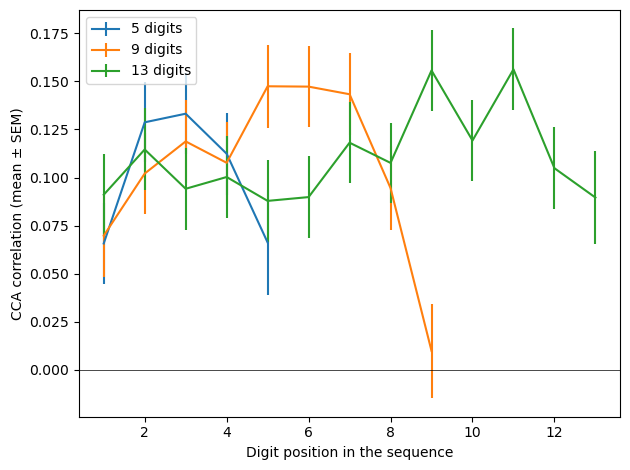

In [6]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    print(f"Subject {subj:03d}")
    best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)
    
    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_memory, best_shift):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)
            cv_eeg = np.dot(eeg_s, weights)
            cv_pupil = pupil_s.ravel()

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]

            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'F1': float(np.mean(eeg_s[w, 5])),  # mean EEG, F1 signal in this digit
                'eeg_component': float(np.mean(x)),  # mean CCA component in this digit
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'memory'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("mem_trial_level_cca_slow.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("mem_digit_level_cca_slow.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

In [ ]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)
    
    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_control, best_shift, win):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)
            cv_eeg = np.dot(eeg_s, weights)
            cv_pupil = pupil_s.ravel()

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]

            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'F1': float(np.mean(eeg_s[w, 5])),  # mean EEG, F1 signal in this digit
                'eeg_component': float(np.mean(x)),  # mean CCA component in this digit
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'control'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("ctrl_trial_level_cca_slow.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("ctrl_digit_level_cca_slow.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

## Comparing mem vs ctrl digits
However since we trained on memory it is biased that memory is significant

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

# --------------------------
# Paths (edit if needed)
# --------------------------
mem_path  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
ctrl_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\ctrl_digit_level_cca_slow.csv")

# --------------------------
# Load and keep needed cols
# --------------------------
cols = ["subject","condition","load","epoch","digit_pos","pupil","eeg","eeg_component","r"]
mem  = pd.read_csv(mem_path)
ctrl = pd.read_csv(ctrl_path)
mem  = mem[[c for c in cols if c in mem.columns]].copy()
ctrl = ctrl[[c for c in cols if c in ctrl.columns]].copy()

digit = 11

# Normalize keys/types
for df in (mem, ctrl):
    df["subject"]   = df["subject"].astype(str).str.strip()
    df["digit_pos"] = pd.to_numeric(df["digit_pos"], errors="coerce")
    for v in ["pupil","eeg","eeg_component","r"]:
        if v in df.columns:
            df[v] = pd.to_numeric(df[v], errors="coerce")

mem["condition"]  = "memory"
ctrl["condition"] = "control"

# --------------------------
# Filter to digit 9 only
# --------------------------
mem9  = mem.query(f"digit_pos == {digit}").copy()
ctrl9 = ctrl.query(f"digit_pos == {digit}").copy()

# --------------------------
# Mean per subject × condition
# (averaged across epochs (and loads if multiple),
#  since you asked for “take the mean for digit 5”)
# --------------------------
vars_ = ["pupil","eeg","eeg_component","r"]
mem_mean  = mem9.groupby(["subject","condition"], as_index=False)[vars_].mean(numeric_only=True)
ctrl_mean = ctrl9.groupby(["subject","condition"], as_index=False)[vars_].mean(numeric_only=True)

# Merge by subject; keep subjects that have BOTH conditions
m = (mem_mean.drop(columns="condition")
         .merge(ctrl_mean.drop(columns="condition"),
                on="subject", suffixes=("_mem","_ctrl")))

if m.empty:
    raise RuntimeError("No subjects have both memory and control data at digit_pos.")

# --------------------------
# Per-subject diffs
# --------------------------
per_subj = pd.DataFrame({"subject": m["subject"]})
for v in vars_:
    mem_v  = m[f"{v}_mem"].astype(float)
    ctrl_v = m[f"{v}_ctrl"].astype(float)
    diff   = mem_v - ctrl_v
    # relative difference vs control (percentage change if you *100)
    # handle |ctrl|=0 -> NaN
    rel    = diff / np.where(np.abs(ctrl_v) > 0, np.abs(ctrl_v), np.nan)

    per_subj[f"{v}_mean_mem"]  = mem_v
    per_subj[f"{v}_mean_ctrl"] = ctrl_v
    per_subj[f"{v}_diff"]      = diff
    per_subj[f"{v}_rel_diff"]  = rel

# Save per-subject table
out_path = Path(f"digit{digit}_per_subject_means_and_diffs.csv")
per_subj.to_csv(out_path, index=False)
print(f"Saved per-subject table: {out_path.resolve()}")

# --------------------------
# Group t-tests across subjects
# One-sample t-test on differences vs 0, one-sided (mean>0)
# --------------------------
def onesided_ttest_greater(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return {"n": len(x), "t": np.nan, "p_one_sided": np.nan}
    t, p_two = stats.ttest_1samp(x, popmean=0.0, nan_policy="omit")
    # one-sided for mean>0
    p_one = p_two/2 if t > 0 else 1 - p_two/2
    return {"n": len(x), "t": float(t), "p_one_sided": float(p_one)}

rows = []
for v in vars_:
    res_rel = onesided_ttest_greater(per_subj[f"{v}_rel_diff"])
    res_abs = onesided_ttest_greater(per_subj[f"{v}_diff"])
    rows.append({
        "variable": v,
        "RELDIFF_n": res_rel["n"],
        "RELDIFF_t": res_rel["t"],
        "RELDIFF_p_one_sided": res_rel["p_one_sided"],
        "RELDIFF_sig_0p05": (res_rel["p_one_sided"] < 0.05) if np.isfinite(res_rel["p_one_sided"]) else False,
        "ABSDIFF_n": res_abs["n"],
        "ABSDIFF_t": res_abs["t"],
        "ABSDIFF_p_one_sided": res_abs["p_one_sided"],
        "ABSDIFF_sig_0p05": (res_abs["p_one_sided"] < 0.05) if np.isfinite(res_abs["p_one_sided"]) else False,
        "mean_rel_diff": np.nanmean(per_subj[f"{v}_rel_diff"].to_numpy(dtype=float)),
        "mean_abs_diff": np.nanmean(per_subj[f"{v}_diff"].to_numpy(dtype=float)),
    })

summary = pd.DataFrame(rows)
sum_path = Path(f"digit{digit}_group_ttests_summary.csv")
summary.to_csv(sum_path, index=False)
print(f"Saved group summary: {sum_path.resolve()}")

print(f"\n=== Group t-tests (digit {digit}) ===")
print(summary.to_string(index=False))


## ANOVA for difference across digits within subjects (memory condition)

In [8]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          56        13 10.524909 3.182266e-19 3.670956e-06       False  2.573540e-08       887.847315              77 3.555389e-137 0.237987     NaN
           F1          56        13  7.780675 1.213224e-13 1.915302e-07       False  1.191575e-01       108.079118              77  1.204230e-02 0.465968     NaN
eeg_component          56        13  5.943199 6.856334e-10 9.264192e-05       False  7.314256e-03       249.858163              77  6.275132e-20 0.357878     NaN
            r          56        13  1.828718 4.041315e-02 1.013765e-01       False  1.717486e-03       323.473581              77  1.212222e-31 0.449325     NaN

Pairwise post-hoc tests:
     variable  A  B         T  dof        p-unc       p-corr p-adjust     cohen
        pupil  1  2  1.323713 55.0 1.910743e-01 2.443245e-01   fdr_bh  0.121958
    

In [9]:
import pandas as pd
from pathlib import Path

# --- Path to your file ---
in_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\pairwise_memory_only.csv")

# --- Read ---
df = pd.read_csv(in_path)

# Safety: normalize column name just in case of stray spaces/casing
df.columns = [c.strip() for c in df.columns]

# --- Filter p-corr < 0.05 ---
sig = df[df['p-corr'] < 0.05].copy().sort_values(['variable','A','B'])

print("Significant pairs (p-corr < 0.05):")
if sig.empty:
    print("None.")
else:
    # Show a compact view
    print(sig[['variable','A','B','T','dof','cohen','p-unc','p-corr']].to_string(index=False))

# --- Save filtered CSV ---
out_csv = in_path.with_name(in_path.stem + "_significant_two.csv")
sig.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


Significant pairs (p-corr < 0.05):
     variable  A  B         T  dof     cohen        p-unc       p-corr
           F1  1  4 -4.502691 55.0 -1.023456 3.532873e-05 2.755641e-04
           F1  1  5 -3.885892 55.0 -0.891223 2.763482e-04 1.658089e-03
           F1  1  6 -4.692100 55.0 -1.033065 1.833943e-05 1.589417e-04
           F1  1  7 -4.445975 55.0 -1.015890 4.290663e-05 3.042470e-04
           F1  1  8 -3.242896 55.0 -0.711929 2.013295e-03 8.265105e-03
           F1  1  9 -4.695127 55.0 -1.082988 1.814680e-05 1.589417e-04
           F1  1 10 -2.340329 55.0 -0.467872 2.292205e-02 4.966445e-02
           F1  1 12 -2.451502 55.0 -0.491833 1.743087e-02 3.998846e-02
           F1  2  3 -5.124406 55.0 -0.739476 3.969745e-06 5.361228e-05
           F1  2  4 -6.535050 55.0 -1.337012 2.173711e-08 1.695495e-06
           F1  2  5 -5.113777 55.0 -1.188139 4.124022e-06 5.361228e-05
           F1  2  6 -6.144090 55.0 -1.310276 9.404952e-08 3.667931e-06
           F1  2  7 -5.559212 55.0 -1.2640

In [10]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem5 = mem[mem["load"] == 5]
mem5["subject"] = mem5["subject"].astype(str).str.strip()
mem5["digit_pos"] = pd.to_numeric(mem5["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem5[v] = pd.to_numeric(mem5[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem5.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory5_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory5_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\3005845650.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem5["subject"] = mem5["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\3005845650.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem5["digit_pos"] = pd.to_numeric(mem5["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\3005845650.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

     variable  n_subjects  n_digits         F        p-unc  p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          42         5  3.408963 1.043959e-02   0.045673       False      0.049480       118.493963               9  3.197216e-21 0.427920     NaN
           F1          42         5 10.111281 2.432113e-07   0.000100       False      0.062738       109.136632               9  2.535158e-19 0.513649     NaN
eeg_component          42         5  6.071508 1.398615e-04   0.003381       False      0.075235       101.976218               9  7.088456e-18 0.504249     NaN
            r          42         5  3.869755 4.955137e-03        NaN        True      0.718539        13.028623               9  1.616599e-01 0.853191     NaN

Pairwise post-hoc tests:
     variable A B         T  dof    p-unc   p-corr p-adjust     cohen
        pupil 1 2  1.455290 41.0 0.153203 0.249286   fdr_bh  0.232614
        pupil 1 3  2.626534 41.0 0

In [11]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem9 = mem[mem["load"] == 9]
mem9["subject"] = mem9["subject"].astype(str).str.strip()
mem9["digit_pos"] = pd.to_numeric(mem9["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem9[v] = pd.to_numeric(mem9[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem9.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory9_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory9_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\857986394.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem9["subject"] = mem9["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\857986394.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem9["digit_pos"] = pd.to_numeric(mem9["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\857986394.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          55         9 13.288967 3.233272e-17 1.192654e-05       False      0.000024       544.665088              35  3.888807e-92 0.234662     NaN
           F1          55         9 13.977219 4.039540e-18 9.844948e-11       False      0.003933       283.149431              35  2.377879e-40 0.535947     NaN
eeg_component          55         9  9.558477 3.271636e-12 4.612185e-05       False      0.250340        70.804765              35  3.345869e-04 0.299247     NaN
            r          55         9  5.129698 4.014703e-06          NaN        True      0.387385        48.483651              35  6.535355e-02 0.799250     NaN

Pairwise post-hoc tests:
     variable A B         T  dof        p-unc       p-corr p-adjust     cohen
        pupil 1 2  1.313325 54.0 1.946266e-01 2.465628e-01   fdr_bh  0.133162
        

In [12]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem13 = mem[mem["load"] == 13]
mem13["subject"] = mem13["subject"].astype(str).str.strip()
mem13["digit_pos"] = pd.to_numeric(mem13["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem13[v] = pd.to_numeric(mem13[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem13.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory13_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory13_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\2868564643.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem13["subject"] = mem13["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\2868564643.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem13["digit_pos"] = pd.to_numeric(mem13["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_10680\2868564643.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


     variable  n_subjects  n_digits        F        p-unc  p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          56        13 7.933904 5.897602e-14   0.000121       False  2.325857e-08       892.988523              77 3.410223e-138 0.223084     NaN
           F1          56        13 4.033187 4.556750e-06   0.001702       False  1.001899e-02       233.871825              77  1.521441e-17 0.404751     NaN
eeg_component          56        13 3.385937 7.982880e-05   0.009180       False  3.953789e-03       281.111246              77  9.023575e-25 0.348859     NaN
            r          56        13 1.136229 3.271322e-01   0.340945       False  7.294717e-03       249.994066              77  5.984965e-20 0.491131     NaN

Pairwise post-hoc tests:
     variable  A  B         T  dof        p-unc   p-corr p-adjust     cohen
        pupil  1  2 -0.607839 55.0 5.457963e-01 0.626060   fdr_bh -0.045230
        pupil  1  3  0.6134

In [15]:
import pandas as pd
from pathlib import Path

# --- Path to your file ---
in_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\pairwise_memory5_only.csv")

# --- Read ---
df = pd.read_csv(in_path)

# Safety: normalize column name just in case of stray spaces/casing
df.columns = [c.strip() for c in df.columns]

# --- Filter p-corr < 0.05 ---
sig = df[df['p-corr'] < 0.05].copy().sort_values(['variable','A','B'])

print("Significant pairs (p-corr < 0.05):")
if sig.empty:
    print("None.")
else:
    # Show a compact view
    print(sig[['variable','A','B','T','dof','cohen','p-unc','p-corr']].to_string(index=False))

# --- Save filtered CSV ---
out_csv = in_path.with_name(in_path.stem + "_significant.csv")
sig.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


Significant pairs (p-corr < 0.05):
     variable  A  B         T  dof     cohen    p-unc   p-corr
           F1  1  4 -2.764081 41.0 -0.776495 0.008513 0.014188
           F1  1  5 -2.765706 41.0 -0.764346 0.008477 0.014188
           F1  2  3 -4.396274 41.0 -0.830570 0.000076 0.000254
           F1  2  4 -4.880947 41.0 -1.277423 0.000016 0.000164
           F1  2  5 -4.635713 41.0 -1.208357 0.000036 0.000180
           F1  3  4 -2.793357 41.0 -0.482462 0.007893 0.014188
eeg_component  1  5 -2.852879 41.0 -0.782333 0.006760 0.016900
eeg_component  2  5 -3.458910 41.0 -0.835365 0.001279 0.012786
eeg_component  3  5 -3.004245 41.0 -0.759489 0.004525 0.015083
eeg_component  4  5 -3.081160 41.0 -0.413264 0.003676 0.015083
        pupil  1  3  2.626534 41.0  0.624250 0.012075 0.030187
        pupil  2  3  2.665346 41.0  0.406516 0.010951 0.030187
        pupil  3  4 -3.598835 41.0 -0.528217 0.000853 0.006111
        pupil  3  5 -3.474617 41.0 -0.677189 0.001222 0.006111
            r  1  3 

In [16]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
bin_map = {
    "early": {1,2,3},
    "mid":   {7,8,9},
    "late":  {11,12,13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned = means.copy()
binned["bin3"] = binned["digit_pos"].map(digit_bin)
binned = binned.dropna(subset=["bin3"])


In [17]:
# --- INVERTED-U: within-subject bin tests using SciPy (no DataFrame indexing gotchas) ---
import numpy as np
from scipy.stats import ttest_rel

def within_subject_bin_tests(df, v):
    # subject-level means per bin (paired design)
    wide = (df[["subject","bin3", v]]
            .dropna()
            .groupby(["subject","bin3"], as_index=False)[v].mean()
            .pivot(index="subject", columns="bin3", values=v))

    # keep subjects with all three bins
    need = {"early","mid","late"}
    if not need.issubset(set(wide.columns)):
        # add any missing columns so .dropna works cleanly
        for col in need - set(wide.columns):
            wide[col] = np.nan
    wide = wide.dropna(subset=["early","mid","late"], how="any")

    n = wide.shape[0]
    if n < 5:
        return None

    # paired arrays
    e = wide["early"].to_numpy(dtype=float)
    m = wide["mid"].to_numpy(dtype=float)
    l = wide["late"].to_numpy(dtype=float)

    # one-sided paired t-tests: H1 mid > early, mid > late
    t_me, p_me = ttest_rel(m, e, alternative="greater")
    t_ml, p_ml = ttest_rel(m, l, alternative="greater")

    # Cohen's dz for paired differences
    def cohen_dz(a, b):
        d = a - b
        return d.mean() / d.std(ddof=1)

    return {
        "n_subjects": int(n),
        "mid>early_t": float(t_me), "mid>early_p": float(p_me), "dz_me": float(cohen_dz(m, e)),
        "mid>late_t":  float(t_ml), "mid>late_p":  float(p_ml), "dz_ml": float(cohen_dz(m, l)),
        "mean(early)": float(e.mean()), "mean(mid)": float(m.mean()), "mean(late)": float(l.mean()),
    }

bin_tests = []
for v in vars_:
    res = within_subject_bin_tests(binned, v)
    if res:
        res["variable"] = v
        bin_tests.append(res)

bin_df = pd.DataFrame(bin_tests)
bin_df.to_csv("invertedU_bin_tests.csv", index=False)
print(bin_df.to_string(index=False))


 n_subjects  mid>early_t  mid>early_p    dz_me  mid>late_t  mid>late_p    dz_ml  mean(early)  mean(mid)  mean(late)      variable
         56     4.387137     0.000026 0.586256    5.007951    0.000003 0.669216    -0.126452   0.244000   -0.058850         pupil
         56     3.339663     0.000756 0.446281    2.345404    0.011321 0.313418    -0.061657   0.097227    0.018306            F1
         56     2.974973     0.002173 0.397547    2.221118    0.015240 0.296809    -0.057781   0.076900    0.018297 eeg_component
         56     0.845132     0.200849 0.112936    1.346057    0.091903 0.179874     0.110519   0.134936    0.110859             r


In [18]:
import statsmodels.formula.api as smf
import numpy as np

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.0094      0.126     55.698      0.000       6.763       7.256
C(subject)[T.sub-034]    -0.1783      0.111     -1.613      0.107      -0.395       0.038
C(subject)[T.sub-035]    -0.0934      0.434     -0.215      0.830      -0.944       0.757
C(subject)[T.sub-036]     0.0698      0.050      1.409      0.159      -0.027       0.167
C(subject)[T.sub-038]     0.1281      0.049      2.592      0.010       0.031       0.225
C(subject)[T.sub-039]     0.0860      0.071      1.214      0.225      -0.053       0.225
C(subject)[T.sub-040]    -0.0912      0.237     -0.384      0.701      -0.557       0.374
C(subject)[T.sub-041]     0.0067      0.080      0.083      0.934      -0.151       0.164
C(subject)[T.sub-042]    -0.0300      0.079     -0.381      0.703      -0.185       0.124
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [20]:
# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("r = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["r"]
p_two = float(m_full.t_test("r = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"r coef = {coef:.3f}, one-sided p = {p_one:.3g}")


Wald test for EEG > 0:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.2936      0.717     -0.409      0.682      -1.699       1.112
r coef = -0.294, one-sided p = 0.659


In [21]:
print("R² =", m_full.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1","eeg_component"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 + eeg_component - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)


R² = 0.030639552027812877  |  Adj. R² = -0.05497761328709583
Within-subject R² = 0.030356935586098532


In [22]:
m_red = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df).fit()
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r +C(subject)", data=df).fit()

SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_full.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) =", partial_R2_eeg)


Partial R² (EEG | F1,pupil) = 0.016088094187533455


In [23]:
import statsmodels.formula.api as smf
import numpy as np


# OLS with subject dummies; cluster SEs by subject
m_not_eeg = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_not_eeg.summary().tables[1])

print("R² =", m_not_eeg.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)



                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.0672      0.043    165.863      0.000       6.984       7.151
C(subject)[T.sub-034]    -0.1646      0.110     -1.496      0.135      -0.380       0.051
C(subject)[T.sub-035]    -0.1930      0.244     -0.792      0.428      -0.670       0.285
C(subject)[T.sub-036]    -0.0318      0.030     -1.072      0.284      -0.090       0.026
C(subject)[T.sub-038]     0.0258      0.026      0.976      0.329      -0.026       0.078
C(subject)[T.sub-039]    -0.0563      0.055     -1.020      0.308      -0.164       0.052
C(subject)[T.sub-040]    -0.2498      0.178     -1.403      0.161      -0.599       0.099
C(subject)[T.sub-041]    -0.0432      0.034     -1.285      0.199      -0.109       0.023
C(subject)[T.sub-042]    -0.0907      0.058     -1.571      0.116      -0.204       0.022
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 57, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [24]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
# mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + eeg_wt", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,F1)
m_red = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + C(subject)", data=mem).fit()
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.036e-18   3.07e-18      0.987      0.323   -2.99e-18    9.06e-18
pupil_wt       0.1203      0.032      3.718      0.000       0.057       0.184
F1_wt          0.1785      0.022      7.980      0.000       0.135       0.222
eeg_wt         0.1450      0.023      6.355      0.000       0.100       0.190
Within-trial R² = 0.008984536304329271
Partial R² (EEG | F1,pupil) at trial-level = 0.002087316232749689


In [25]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned.dropna(subset=["subject","bin3","F1","pupil","eeg_component","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1","pupil"],
    "F1+pupil+EEG":  ["F1","pupil","eeg_component"],
    "EEG only":      ["eeg_component"],
    "F1 only":       ["F1"],
    "pupil only":    ["pupil"],
    "All 4":         ["F1","pupil","eeg_component","r"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                    features  accuracy  macro_f1
    F1+pupil                   F1, pupil  0.496032  0.485655
F1+pupil+EEG    F1, pupil, eeg_component  0.480159  0.473440
       All 4 F1, pupil, eeg_component, r  0.474206  0.468133
  pupil only                       pupil  0.462302  0.436508
     F1 only                          F1  0.446429  0.413730
    EEG only               eeg_component  0.414683  0.399718

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.495     0.536     0.514       168
        late      0.468     0.310     0.373       168
         mid      0.512     0.643     0.570       168

    accuracy                          0.496       504
   macro avg      0.492     0.496     0.486       504
weighted avg      0.492     0.496     0.486       504

Normalized confusion matrix (rows sum to 1):
            pred_early  pred_late  pred_mid
true_earl

In [26]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2, 3},
    "mid":   {7, 8, 9},
    "late":  {11, 12, 13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [27]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3","F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.403309  0.376564
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.402590  0.376292
    F1+pupil            F1_wt, pupil_wt  0.393351  0.365747
   pupil+EEG           pupil_wt, eeg_wt  0.381158  0.361533
     F1 only                      F1_wt  0.443826  0.354047
    EEG only                     eeg_wt  0.435912  0.346941
  pupil only                   pupil_wt  0.329509  0.312097

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.554     0.334     0.416     13290
        late      0.175     0.270     0.212      4386
         mid      0.410     0.546     0.469      8733

    accuracy                          0.393     26409
   macro avg      0.380     0.383     0.366     26409
weighted avg      0.443     0.393     0.400     26409

Normalized confusion matrix (rows sum to 1):


## RECALL ACCURACY

In [28]:
import pandas as pd
from pathlib import Path
from scipy import stats

corr = (pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
          .assign(                       # extract trial #, then +1 to match *.tsv
              trial=lambda d:
                  d.epoch.str.extract(r"trial_(\d+)\.csv")
                    .astype(int).squeeze()
                    + 1                 # 0-based → 1-based
          ))
#corr = corr[corr["load"] == 9]
BEH_DIR    = Path(r"C:\Users\cdd\Documents\Uni\Special_course\ds003838-download")

In [29]:
grp = corr.groupby(["subject","epoch"])
corr["digit_pos_wt"] = corr["digit_pos"] - grp["digit_pos"].transform("mean")
corr["pupil_wt"]     = corr["pupil"]     - grp["pupil"].transform("mean")
corr["F1_wt"]        = corr["F1"]        - grp["F1"].transform("mean")
corr["r_wt"]        = corr["r"]          - grp["r"].transform("mean")
corr["eeg_wt"]       = corr["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = corr[c].mean(), corr[c].std(ddof=1)
    if sd > 0: corr[c] = (corr[c] - mu)/sd

In [30]:
def explode_triggers(df_beh):
    out_frames = []
    for _, row in df_beh.iterrows():
        trig = row["triggerCorrect"].strip()
        out_frames.append(pd.DataFrame({
            "trial"     : row["trial"],
            "digit_pos" : range(1, len(trig) + 1),   # 1, 2, …
            "recalled"  : [int(c) for c in trig]      # 0 / 1
        }))
    return pd.concat(out_frames, ignore_index=True)


In [31]:
subject_dfs = []      # collect for an optional grand-average
stats_per_sub = []    # store per-subject t-tests

for sub in corr["subject"].unique():
    # --- Behaviour ------------------------------------------------------
    beh_path = (BEH_DIR / sub / "beh" / f"{sub}_task-memory_beh.tsv")
    beh_raw  = pd.read_csv(beh_path, sep="\t", usecols=["trial", "triggerCorrect"], dtype = {"triggerCorrect": str})
    beh      = explode_triggers(beh_raw)

    # --- Merge ----------------------------------------------------------
    merged = corr.query("subject == @sub").merge(
                 beh, on=["trial", "digit_pos"], how="inner")

    # --- Stats ----------------------------------------------------------
    rec  = merged.loc[merged.recalled == 1, "r"]
    miss = merged.loc[merged.recalled == 0, "r"]

    t, p = stats.ttest_ind(rec, miss, equal_var=False)
    stats_per_sub.append(
        {"subject": sub,
         "mean_r_recalled": rec.mean(),
         "mean_r_missed"  : miss.mean(),
         "t" : t, "p" : p, "n_recalled": len(rec), "n_missed": len(miss)}
    )

    merged["subject"] = sub
    subject_dfs.append(merged)


In [32]:
subject_df = pd.concat(subject_dfs, ignore_index=True, sort=False)

In [33]:
print(f"sub {sub}:  n_raecalled = {len(rec)},  var = {rec.var(ddof=1):.3g}, mean = {rec.mean():.3g} ")
print(f"sub {sub}:  n_missed   = {len(miss)}, var = {miss.var(ddof=1):.3g}, mean = {miss.mean():.3g}")


sub sub-098:  n_raecalled = 173,  var = 0.637, mean = 0.186 
sub sub-098:  n_missed   = 214, var = 0.678, mean = 0.217


In [34]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df_corr = subject_df.dropna(subset=["subject","recalled","F1_wt","pupil_wt","eeg_wt","r_wt"]).copy()
df_corr["recalled"] = df_corr["recalled"].astype("category")
y = df_corr["recalled"].values
groups = df_corr["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df_corr[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df_corr = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df_corr.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df_corr = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df_corr.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
  pupil only                   pupil_wt  0.517531  0.515776
    F1+pupil            F1_wt, pupil_wt  0.516030  0.514954
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.515674  0.514838
   pupil+EEG           pupil_wt, eeg_wt  0.516131  0.514530
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.513231  0.512497
    EEG only                     eeg_wt  0.511552  0.510459
     F1 only                      F1_wt  0.500814  0.500810

--- F1+pupil ---
              precision    recall  f1-score   support

           0      0.565     0.513     0.538     21583
           1      0.467     0.520     0.492     17719

    accuracy                          0.516     39302
   macro avg      0.516     0.516     0.515     39302
weighted avg      0.521     0.516     0.517     39302

Normalized confusion matrix (rows sum to 1):
        pred_0  pred_1
true_0   0.513   0.487
true_1  